<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 105.5 MB/s eta 0:00:00


Import pandas module


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

Import matplotlib


In [3]:
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [11]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")
df.shape

(65457, 114)

## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
## Write your code here
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 20


In [8]:
df[df.duplicated()].head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [7]:
duplicates = df[df.duplicated()]

print("Duplicate rows:", duplicates.shape[0])

duplicates.head()

Duplicate rows: 20


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [9]:
## Write your code here

# Identify response-pattern duplicates

pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Rows sharing the same response pattern
pattern_duplicates = df[df.duplicated(subset=pattern_cols, keep=False)]

print("Rows sharing the same response pattern:")
print(pattern_duplicates.shape[0])

pattern_duplicates.head()

Rows sharing the same response pattern:
65290


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [13]:
# Count unique response patterns

pattern_counts = (
    df.groupby(pattern_cols)
      .size()
      .reset_index(name='count')
      .sort_values(by='count', ascending=False)
)

pattern_counts.head(10)

,MainBranch,Employment,RemoteWork,count
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
2,I am a developer by profession,"Employed, full-time",Remote,12196
1,I am a developer by profession,"Employed, full-time",In-person,7118
78,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
8,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754
232,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",1479
6,I am a developer by profession,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",1169
76,I am a developer by profession,"Independent contractor, freelancer, or self-em...","Hybrid (some remote, some in-person)",990
233,"I am not primarily a developer, but I write co...","Employed, full-time",In-person,916
234,"I am not primarily a developer, but I write co...","Employed, full-time",Remote,695


In [ ]:
# Clarify interpretation

#These are not duplicate records. They represent: Multiple respondents who provided identical answers to selected survey questions.
# So the rows may still differ in:
#age
#country
#salary
#education
#programming language
#others

In [14]:
# Analyze which other columns are frequently identical within groups

# Columns to inspect
other_cols = [col for col in df.columns if col not in pattern_cols]

# For each pattern group, count unique values per column
group_consistency = (
    pattern_duplicates
    .groupby(pattern_cols)[other_cols]
    .nunique()
)

group_consistency.head()


ResponseId  \
MainBranch                     Employment                              RemoteWork                                         
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)       15286   
                                                                       In-person                                   7118   
                                                                       Remote                                     12191   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)          78   
                                                                       In-person                                     25   

                                                                                                             Age  \
MainBranch                     Employment                              RemoteWork                                  
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)    8   
                                                                       In-person                               8   
                                                                       Remote                                  8   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)    5   
                                                                       In-person                               2   

                                                                                                             Check  \
MainBranch                     Employment                              RemoteWork                                    
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)      1   
                                                                       In-person                                 1   
                                                                       Remote                                    1   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)      1   
                                                                       In-person                                 1   

                                                                                                             CodingActivities  \
MainBranch                     Employment                              RemoteWork                                               
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)                90   
                                                                       In-person                                           79   
                                                                       Remote                                              87   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-person)                29   
                                                                       In-person                                           16   

                                                                                                             EdLevel  \
MainBranch                     Employment                              RemoteWork                                      
I am a developer by profession Employed, full-time                     Hybrid (some remote, some in-person)        8   
                                                                       In-person                                   8   
                                                                       Remote                                      8   
                               Employed, full-time;Employed, part-time Hybrid (some remote, some in-per

In [15]:
# Find columns most frequently identical

# Columns with many "1" indicate respondents in the same pattern group often share identical values.

# Percentage of groups with only one unique value
consistency_summary = (
    (group_consistency == 1)
    .mean()
    .sort_values(ascending=False)
)

consistency_summary.head(15)

Check                            1.000000
ICorPM                           0.304075
AIThreat                         0.275862
SOAccount                        0.266458
AINextLess integrated            0.238245
SurveyLength                     0.235110
AISelect                         0.235110
AINextMuch more integrated       0.231975
SOPartFreq                       0.210031
AINextNo change                  0.210031
AIToolNot interested in Using    0.210031
AIComplex                        0.200627
MiscTechAdmired                  0.191223
PlatformWantToWorkWith           0.191223
EmbeddedWantToWorkWith           0.188088
dtype: float64

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [16]:
## Write your code here

pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Keep all rows belonging to duplicated response patterns
shared_patterns = df[df.duplicated(subset=pattern_cols, keep=False)]

print("Rows with shared response patterns:", shared_patterns.shape[0])

shared_patterns.head()

Rows with shared response patterns: 65290


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [18]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

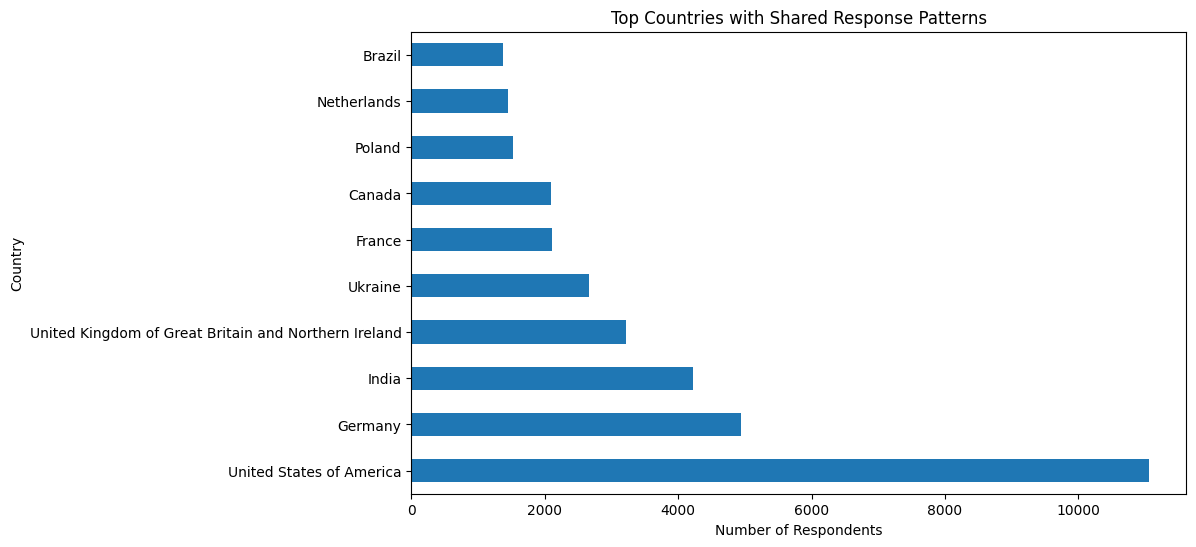

In [23]:
# Bar chart: shared response patterns by Country

country_counts = (
    shared_patterns['Country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
country_counts.plot(kind='barh')

plt.title('Top Countries with Shared Response Patterns')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')

#plt.xticks(rotation=45)
plt.show()

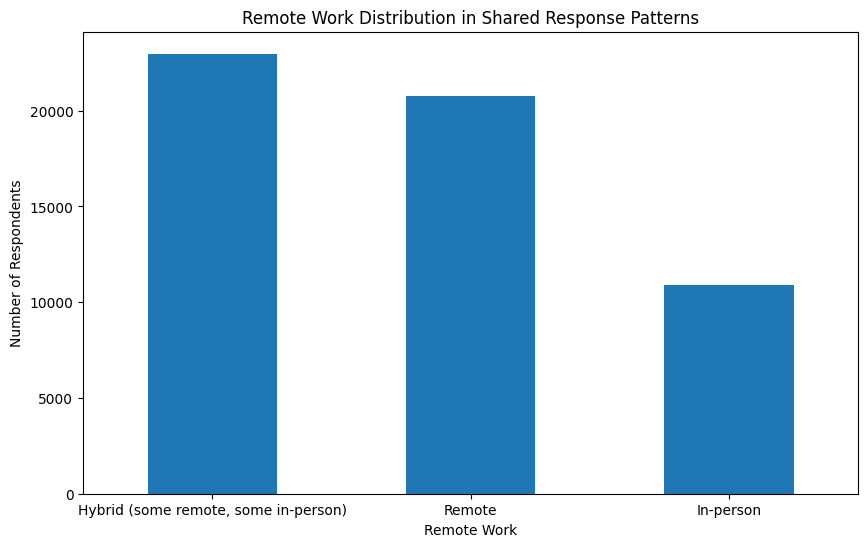

In [27]:
# Bar chart: shared response patterns by RemoteWork

remote_counts = shared_patterns['RemoteWork'].value_counts()

plt.figure(figsize=(10,6))
remote_counts.plot(kind='bar')

plt.title('Remote Work Distribution in Shared Response Patterns')
plt.xlabel('Remote Work')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=0)
plt.show()


In [30]:
# Inspectioning emplyment category, and realizing that it has a lot of unique values, not great for plotting

employment_counts = (
    shared_patterns['Employment']
    .value_counts()
)

employment_counts.nunique()

49

In [32]:
# Creating a new column that captures the employment categories in broader groups

def simplify_employment(x):

    first = x.split(';')[0]

    if first.startswith('Employed'):
        return 'Employed'

    elif first.startswith('Independent'):
        return 'Independent'

    elif first.startswith('Student'):
        return 'Student'

    elif 'but looking for work' in first:
        return 'Unemployed - Looking'

    elif 'and not looking for work' in first:
        return 'Unemployed - Not Looking'

    elif first.startswith('Retired'):
        return 'Retired'

    else:
        return 'Other'

shared_patterns['Employment_Group'] = shared_patterns['Employment'].apply(simplify_employment)

shared_patterns['Employment_Group'].value_counts()

Employment_Group
Employed                    46386
Student                      8571
Independent                  5551
Unemployed - Looking         3009
Unemployed - Not Looking      701
Other                         546
Retired                       526
Name: count, dtype: int64

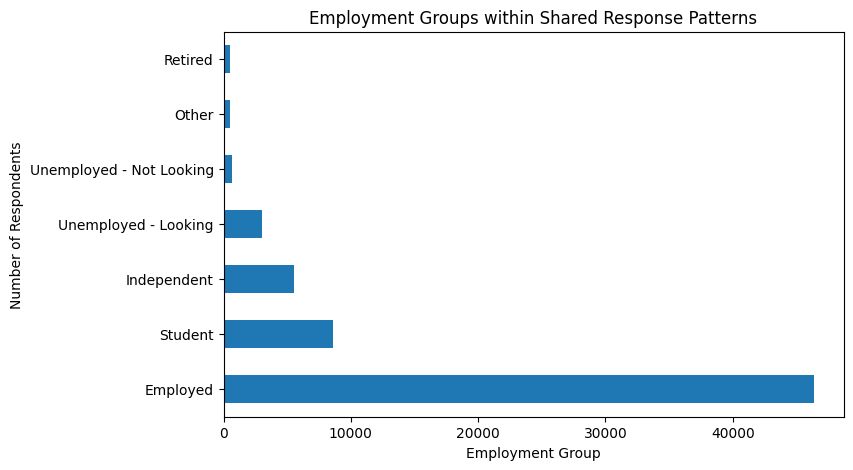

In [34]:
# Bar chart of shared responses patterns by broader Employment Groups

employment_counts = shared_patterns['Employment_Group'].value_counts()

plt.figure(figsize=(8,5))
employment_counts.plot(kind='barh')

plt.title('Employment Groups within Shared Response Patterns')
plt.xlabel('Employment Group')
plt.ylabel('Number of Respondents')

#plt.xticks(rotation=45)
plt.show()

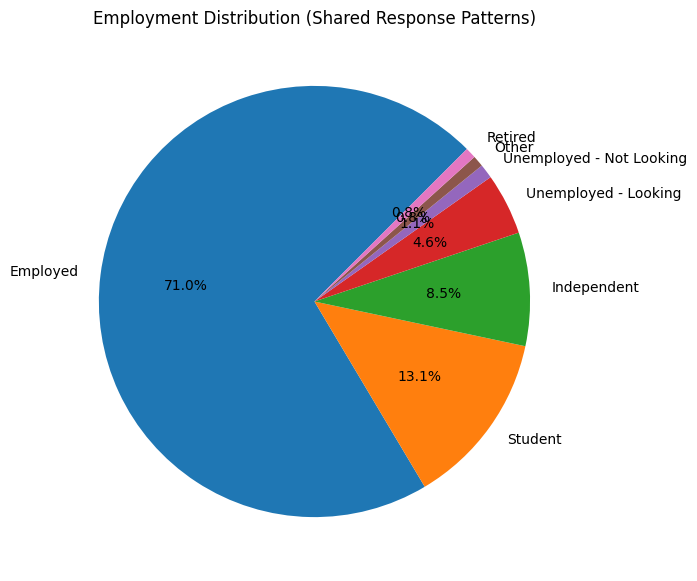

In [36]:
# Pie chart of shared responses patterns by broader Employment Groups

plt.figure(figsize=(7,7))

plt.pie(
    employment_counts,
    labels=employment_counts.index,
    autopct='%1.1f%%',
    startangle=45
)

plt.title('Employment Distribution (Shared Response Patterns)')
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [38]:
## Write your analysis here

# In this dataset, each row represents one survey respondent, meaning record uniqueness is defined by the entire row across all columns.

# So, record-level duplicates are full-row duplication

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 20


In [ ]:
# Record uniqueness is defined by the full row. 
# Therefore, only complete duplicate rows should be removed. 
# Subset-based duplication should NOT be used for deletion, as it represents meaningful variation among respondents rather than data errors.

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


In [39]:
# Write your explanation here 

# For identifying Duplicate Rows the following code can be used: df.duplicated().sum()

# This method checks for fully identical rows across all columns.

# In this dataframe, the result is 20 duplicate rows. These represent exact repeated records in the dataset.

# To ensure data integrity, only true duplicates (full-row matches) were removed. This ensures: each respondent is represented once, 
# no artificial inflation of sample size, and no distortion of distributions

df = df.drop_duplicates()

In [43]:
# the shape of the df before eliminating 20 duplicate rows was (65457, 114); after eliminating duplicates is (65437, 114)

print('Row and columns after dropping duplicates is:', df.shape)

Row and columns after dropping duplicates is: (65437, 114)


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


In [ ]:
# Write your explanation here

# Final justification: Full-row duplication was used because only complete matches indicate true duplicate records. 
# Subset-based duplication reflects similarity in responses, not duplicate entries, and therefore was not used for removal to preserve
# data integrity and analytical validity.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
